# ***Heart Disease Prediction***
----

In [67]:
# Importar función de carga
from ucimlrepo import fetch_ucirepo

# Importar librerías para preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Importar librerías para análisis de datos y visualización
import matplotlib.pyplot as plt
import seaborn as sns


In [50]:
# Descargar el dataset con ID = 45 (Heart Disease)
heart_disease = fetch_ucirepo(id=45)

In [51]:
# Features (X) y Target (y)
X = heart_disease.data.features   # Variables predictoras
y = heart_disease.data.targets    # Variable objetivo (presencia de enfermedad)

# Metadatos del dataset
heart_disease.metadata

{'uci_id': 45,
 'name': 'Heart Disease',
 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease',
 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv',
 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach',
 'area': 'Health and Medicine',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 303,
 'num_features': 13,
 'feature_types': ['Categorical', 'Integer', 'Real'],
 'demographics': ['Age', 'Sex'],
 'target_col': ['num'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1989,
 'last_updated': 'Fri Nov 03 2023',
 'dataset_doi': '10.24432/C52P4X',
 'creators': ['Andras Janosi',
  'William Steinbrunn',
  'Matthias Pfisterer',
  'Robert Detrano'],
 'intro_paper': {'ID': 231,
  'type': 'NATIVE',
  'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.',
  'authors': 'R. Detr

In [52]:
heart_disease.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


---
***EDA***
---
---

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
# Revisar estructura de los datos
print("Dimensiones X:", X.shape)
print("Dimensiones y:", y.shape)

Dimensiones X: (303, 13)
Dimensiones y: (303, 1)


In [55]:
print("\nInfo de X:")
print(X.info())


Info de X:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB
None


In [56]:
print("\nDescripción estadística:")
print(X.describe())


Descripción estadística:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  299.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600660    0.672241   
s

In [57]:
# Unir X e y para análisis conjunto
df = X.copy()
df['target'] = y

In [58]:
# Visualizar los primeros registros
print("\nPrimeros registros:")
df.head(15)


Primeros registros:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


---
**Visualizacion exploratoria de datos**

---

C:\Users\apalombo\AppData\Local\Temp\ipykernel_13760\2460009866.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


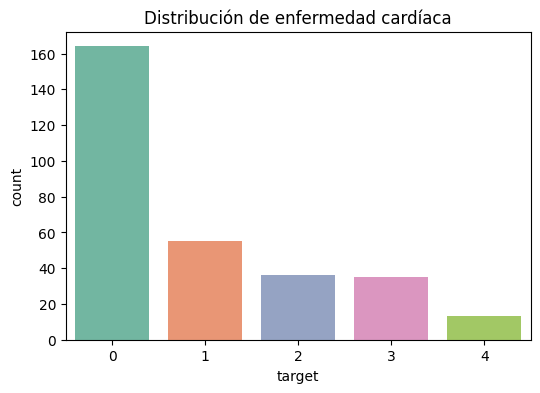

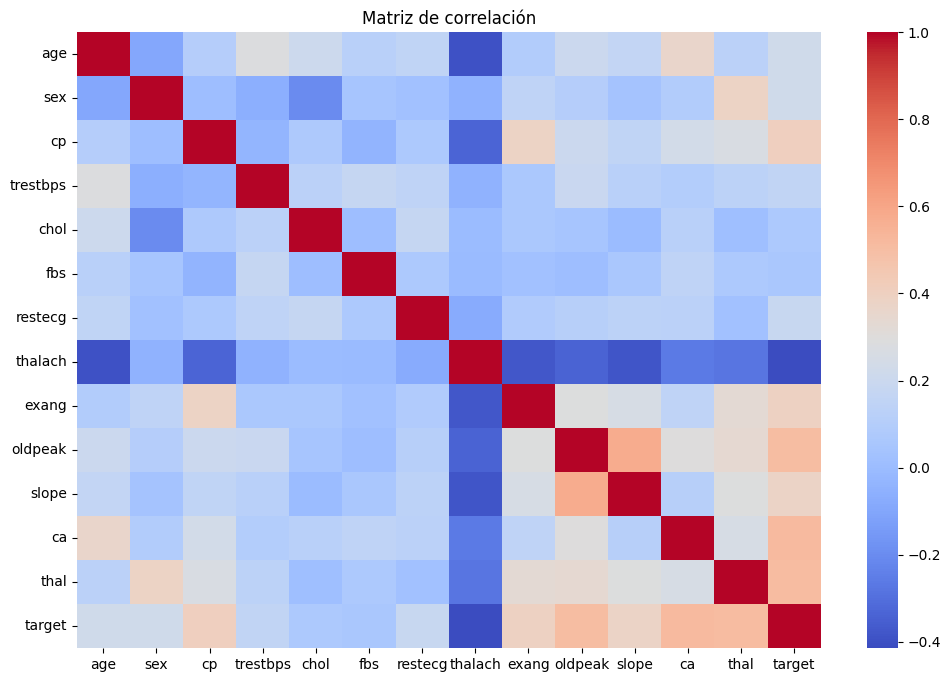

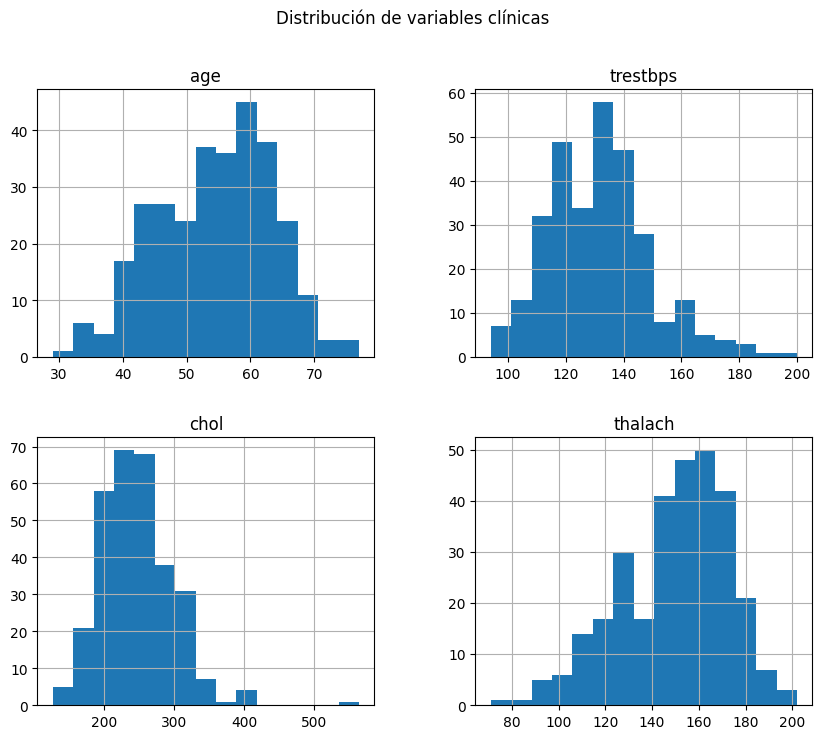

In [59]:
# --- Distribucion de la variable objetivo ---

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribución de enfermedad cardíaca')
plt.show()

# --- Correlación entre variables ---
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm", cbar=True)
plt.title("Matriz de correlación")
plt.show()

# --- Distribución de algunas variables importantes ---
features = ["age", "trestbps", "chol", "thalach"]
df[features].hist(figsize=(10,8), bins=15)
plt.suptitle("Distribución de variables clínicas")
plt.show()

---
**Limpieza de datos**

---

Valores nulos por columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Número de filas antes de eliminar duplicados: 303
Número de filas después de eliminar duplicados: 303

Tipos de datos:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object

Valores nulos después de reemplazo:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


C:\Users\apalombo\AppData\Local\Temp\ipykernel_13760\2262071924.py:22: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


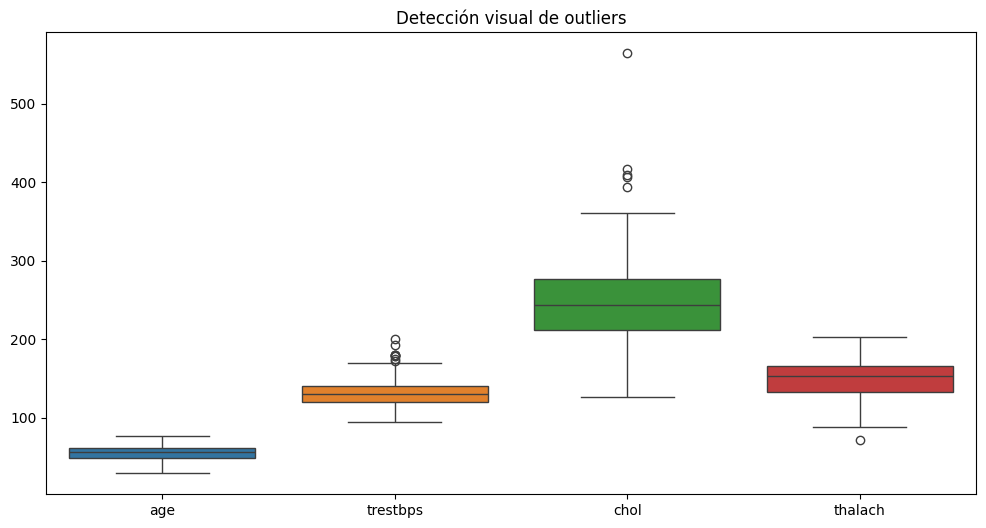

In [60]:
# --- 1. Revisar valores nulos ---
print("Valores nulos por columna:")
print(df.isnull().sum())

# --- 2. Eliminar duplicados ---
print("\nNúmero de filas antes de eliminar duplicados:", df.shape[0])
df = df.drop_duplicates()
print("Número de filas después de eliminar duplicados:", df.shape[0])

# --- 3. Revisar tipos de datos ---
print("\nTipos de datos:")
print(df.dtypes)

# --- 4. Reemplazar valores inconsistentes ---
# La columna 'ca' y 'thal' pueden tener valores faltantes codificados como '?'
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"Valores únicos en {col}:", df[col].unique())

# Convertimos a numérico si hay '?'
df = df.replace('?', pd.NA)
df = df.apply(pd.to_numeric, errors='ignore')

# --- 5. Revisar de nuevo valores nulos ---
print("\nValores nulos después de reemplazo:")
print(df.isnull().sum())

# eliminar o imputar valores faltantes
df = df.dropna()

# --- 6. Outliers rápidos ---

plt.figure(figsize=(12,6))
sns.boxplot(data=df[["age", "trestbps", "chol", "thalach"]])
plt.title("Detección visual de outliers")
plt.show()


---
***Procesamiento y Split***
---
---

In [61]:
# Separar X e y
X = df.drop(columns=['target'])
y = df['target']   # multiclase (0–4)

# Identificar columnas numéricas y categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Columnas numéricas:", list(num_cols))
print("Columnas categóricas:", list(cat_cols))

# Pipeline de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Tamaño train:", X_train.shape, "Tamaño test:", X_test.shape)

Columnas numéricas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Columnas categóricas: []
Tamaño train: (237, 13) Tamaño test: (60, 13)


**Cross-Validation**

#### ¿Por qué CV?

- Dataset pequeño (~303 filas): un único split puede dar estimaciones inestables.

- Desbalance entre clases (0–4): la estratificación ayuda a mantener proporciones por clase en cada fold.

- Comparación justa de modelos: CV reduce la varianza de la métrica y evita “sobreajustar” al split de validación.

- Métrica adecuada: usaremos F1 macro y balanced accuracy (sensibles a desbalance).

---
**Logistic Regression**

---

In [62]:
# Pipelines baseline (LR)

baseline = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(multi_class="multinomial", max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "bal_acc": "balanced_accuracy",
    "f1_macro": "f1_macro"
}

cv_results = cross_validate(
    baseline, X_train, y_train, 
    cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
)

print("CV (5-fold) — Accuracy:      ", cv_results["test_accuracy"].mean(), "±", cv_results["test_accuracy"].std())
print("CV (5-fold) — F1 macro:      ", cv_results["test_f1_macro"].mean(), "±", cv_results["test_f1_macro"].std())
print("CV (5-fold) — Balanced Acc.: ", cv_results["test_bal_acc"].mean(), "±", cv_results["test_bal_acc"].std())

CV (5-fold) — Accuracy:       0.5444148936170212 ± 0.04968052201712427
CV (5-fold) — F1 macro:       0.26667397656224273 ± 0.024972922124130523
CV (5-fold) — Balanced Acc.:  0.27042564102564104 ± 0.030153308520896573


In [63]:
pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(multi_class="multinomial", max_iter=1000))
])

param_grid = {
    "clf__C": [0.1, 1, 3, 10],
    "clf__penalty": ["l2"],  # (LR multinomial + “lbfgs” usa L2)
    "clf__solver": ["lbfgs"]
}

grid = GridSearchCV(
    pipe, param_grid=param_grid, cv=cv,
    scoring="f1_macro", n_jobs=-1, refit=True
)

grid.fit(X_train, y_train)

print("Mejor F1 macro (CV):", grid.best_score_)
print("Mejores params:", grid.best_params_)
best_model = grid.best_estimator_

Mejor F1 macro (CV): 0.26974059161483094
Mejores params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


C:\Users\apalombo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


== Evaluación final en TEST ==
              precision    recall  f1-score   support

           0      0.789     0.938     0.857        32
           1      0.400     0.182     0.250        11
           2      0.000     0.000     0.000         7
           3      0.300     0.429     0.353         7
           4      0.000     0.000     0.000         3

    accuracy                          0.583        60
   macro avg      0.298     0.310     0.292        60
weighted avg      0.529     0.583     0.544        60



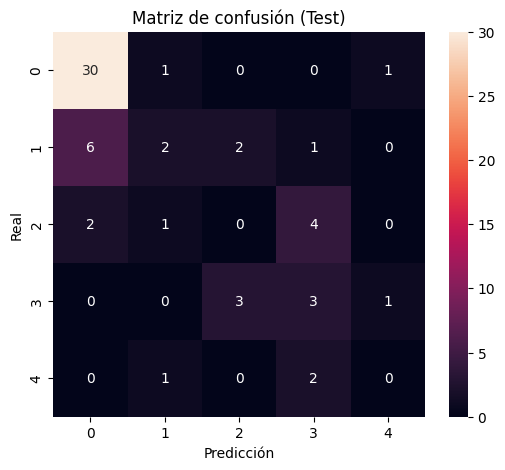

In [ ]:
# Evaluacion final en test

y_pred = best_model.predict(X_test)

print("== Evaluación final en TEST ==")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.title("Matriz de confusión (Test)")
plt.show()

---
**Random Forest**

---